In [2]:
# Importing packages
import pyspark.sql.functions as F
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Nice to have in notebooks
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

def parse_dnr(d):
    """
    'D0411' -> 411
    'D1354' -> 1354
    """
    s = str(d).strip()
    if not s or not s.startswith("D"):
        return None
    digits = s[1:].lstrip("0")  # remove 'D' and leading zeros
    if digits == "":
        return None
    return int(digits)


In [3]:
# Paths assuming notebook is in src/phasebalance
sm_path = "../data/smartmeter_15min_all_from_devices_20251101_20251103_test.parquet"
jn_path = "../data/janitza_15min_all_20251101_1200_20251103_1200.parquet"

df_sm = pd.read_parquet(sm_path)
df_jn = pd.read_parquet(jn_path)

# List of substations / dnr_str values you want to exclude
exclude_dnr = ["D0006", "D1133","D1554"]  # add more here later

df_jn = df_jn[~df_jn["dnr_str"].isin(exclude_dnr)].copy()


print("Smartmeter shape:", df_sm.shape)
print("Janitza shape   :", df_jn.shape)
print("Smartmeter cols:", df_sm.columns.tolist())
print("Janitza cols   :", df_jn.columns.tolist())


Smartmeter shape: (16405, 8)
Janitza shape   : (12482, 6)
Smartmeter cols: ['substation_id', 'ts', 'I_a', 'I_b', 'I_c', 'I_total', 'n_mps', 'per_completed']
Janitza cols   : ['ts', 'I_a', 'I_b', 'I_c', 'I_total', 'dnr_str']


In [4]:
# 1) Parse dnr_str -> substation_id on the Janitza side
df_jn["substation_id"] = df_jn["dnr_str"].map(parse_dnr)

# 2) Ensure timestamps are datetime
df_sm["ts"] = pd.to_datetime(df_sm["ts"])
df_jn["ts"] = pd.to_datetime(df_jn["ts"])

# 3) Sort for sanity
df_sm = df_sm.sort_values(["substation_id", "ts"])
df_jn = df_jn.sort_values(["substation_id", "ts"])

print("Example smartmeter substations:", df_sm["substation_id"].dropna().unique()[:10])
print("Example Janitza substations  :", df_jn["substation_id"].dropna().unique()[:10])


Example smartmeter substations: [  6  29  55  74  76 173 176 202 246 263]
Example Janitza substations  : [ 29  55  74  76 173 176 202 246 263 383]


In [5]:
# Force both ts columns to be UTC -> then drop timezone (naive but aligned)
df_sm["ts"] = pd.to_datetime(df_sm["ts"], utc=True).dt.tz_localize(None)
df_jn["ts"] = pd.to_datetime(df_jn["ts"], utc=True).dt.tz_localize(None)

print("df_sm ts dtype:", df_sm["ts"].dtype)
print("df_jn ts dtype:", df_jn["ts"].dtype)



# Merge on substation_id + ts (inner join = only overlapping timestamps)
merged = df_sm.merge(
    df_jn,
    on=["substation_id", "ts"],
    how="inner",
    suffixes=("_sm", "_jn"),
)

print("Merged shape:", merged.shape)
merged[["substation_id", "ts"]].head()

for col in ["I_a", "I_b", "I_c", "I_total"]:
    merged[f"{col}_diff"] = merged[f"{col}_sm"] - merged[f"{col}_jn"]

merged[["I_a_diff", "I_b_diff", "I_c_diff", "I_total_diff"]].describe()


df_sm ts dtype: datetime64[ns]
df_jn ts dtype: datetime64[ns]
Merged shape: (11328, 13)


,I_a_diff,I_b_diff,I_c_diff,I_total_diff
count,11328.000000,11328.000000,11328.000000,11328.000000
mean,61.522419,-44.178087,-37.742229,-20.397897
std,205.461466,204.246750,195.248880,544.753324
min,-888.232898,-1586.371496,-1376.864009,-3519.917121
25%,-16.477387,-103.195413,-93.988375,-151.648242
50%,44.862080,-35.892430,-25.589260,-21.316370
75%,166.658274,2.446145,3.966118,89.691596
max,1207.604656,1214.029423,1228.472637,3650.106716


Rows for substation 1400 : 192


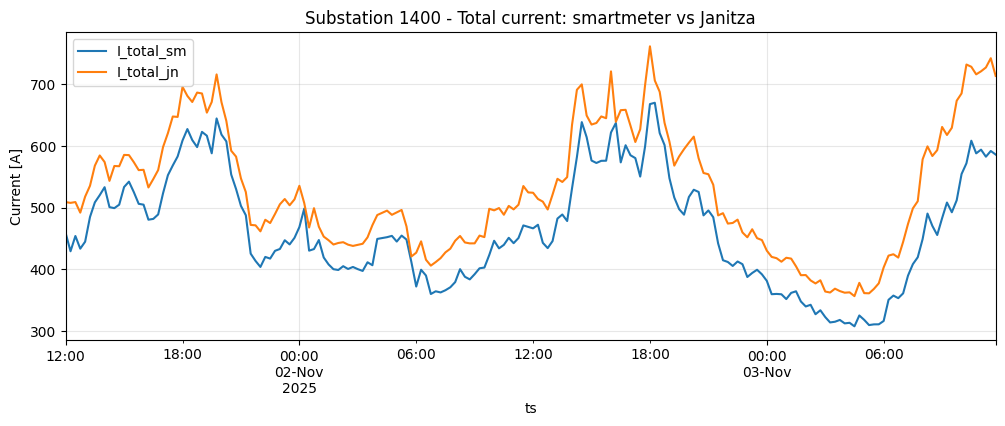

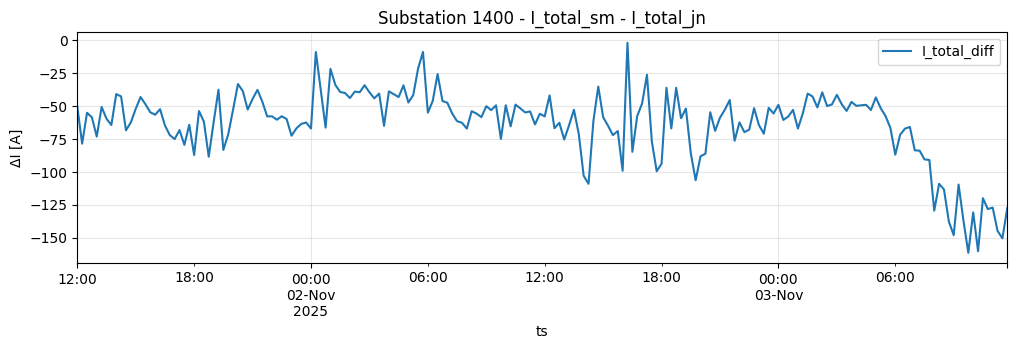

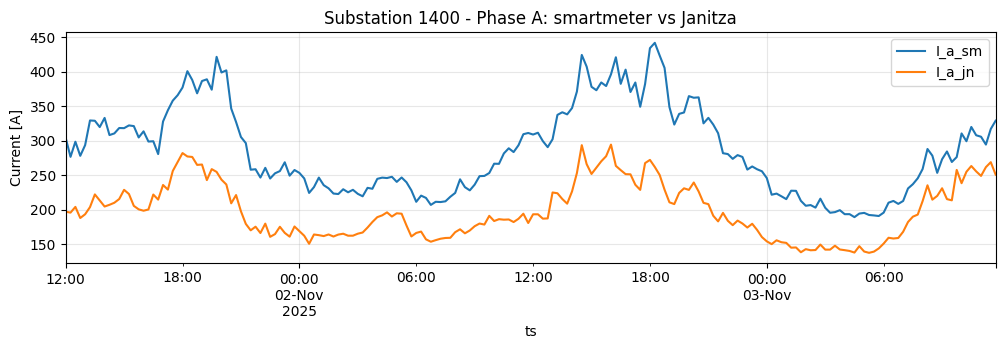

In [6]:
sub = 1400  # change this to whatever you want

sub_df = (
    merged[merged["substation_id"] == sub]
    .set_index("ts")
    .sort_index()
)

print("Rows for substation", sub, ":", sub_df.shape[0])
sub_df[["I_total_sm", "I_total_jn", "I_total_diff"]].head()

ax = sub_df[["I_total_sm", "I_total_jn"]].plot(
    figsize=(12, 4),
    title=f"Substation {sub} - Total current: smartmeter vs Janitza",
)
ax.set_ylabel("Current [A]")
ax.grid(True, alpha=0.3)
plt.show()

ax2 = sub_df[["I_total_diff"]].plot(
    figsize=(12, 3),
    title=f"Substation {sub} - I_total_sm - I_total_jn",
)
ax2.set_ylabel("ΔI [A]")
ax2.grid(True, alpha=0.3)
plt.show()

ax3 = sub_df[["I_a_sm", "I_a_jn"]].plot(
    figsize=(12, 3),
    title=f"Substation {sub} - Phase A: smartmeter vs Janitza",
)
ax3.set_ylabel("Current [A]")
ax3.grid(True, alpha=0.3)
plt.show()


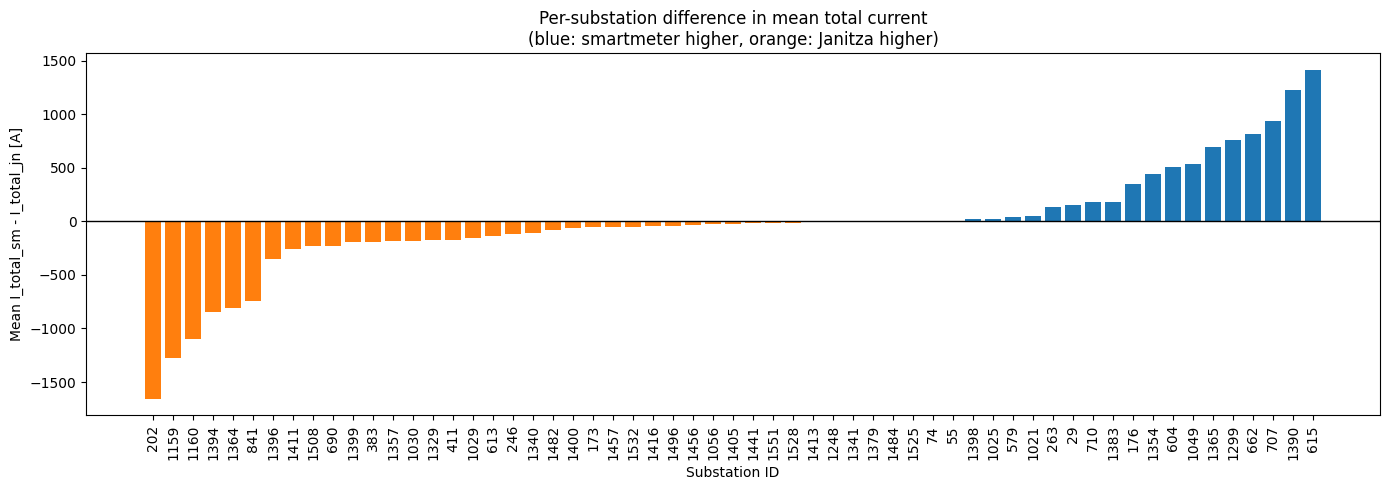

In [7]:

sub_stats = (
    merged
    .groupby("substation_id")
    .agg(
        mean_I_total_sm = ("I_total_sm", "mean"),
        mean_I_total_jn = ("I_total_jn", "mean"),
        mean_diff       = ("I_total_diff", "mean"),      # same as above two minus each other
    )
)

# (Optional) sort by difference so the bar chart is easier to read
sub_stats = sub_stats.sort_values("mean_diff")

# 2) Prepare data for plotting
x = np.arange(len(sub_stats))
y = sub_stats["mean_diff"].values
subs = sub_stats.index.astype(int)

# Color: blue if smartmeter > Janitza, orange otherwise
colors = ["tab:blue" if val > 0 else "tab:orange" for val in y]

# 3) Plot
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(x, y, color=colors)

ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(subs, rotation=90)
ax.set_xlabel("Substation ID")
ax.set_ylabel("Mean I_total_sm - I_total_jn [A]")
ax.set_title("Per-substation difference in mean total current\n"
             "(blue: smartmeter higher, orange: Janitza higher)")

plt.tight_layout()
plt.show()


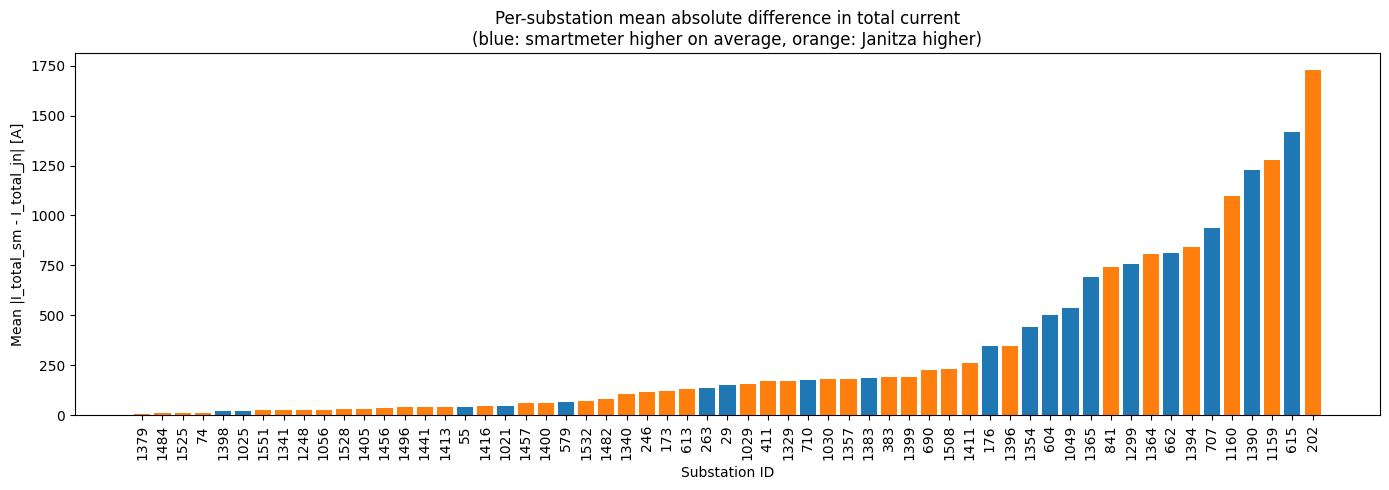

In [8]:
sub_stats["mean_abs_diff"] = (
    merged
    .groupby("substation_id")["I_total_diff"]
    .apply(lambda s: s.abs().mean())
)

sub_stats = sub_stats.sort_values("mean_abs_diff")

x = np.arange(len(sub_stats))
height = sub_stats["mean_abs_diff"].values
sign   = sub_stats["mean_diff"].values  # from previous aggregation
colors = ["tab:blue" if val > 0 else "tab:orange" for val in sign]
subs   = sub_stats.index.astype(int)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x, height, color=colors)

ax.set_xticks(x)
ax.set_xticklabels(subs, rotation=90)
ax.set_xlabel("Substation ID")
ax.set_ylabel("Mean |I_total_sm - I_total_jn| [A]")
ax.set_title("Per-substation mean absolute difference in total current\n"
             "(blue: smartmeter higher on average, orange: Janitza higher)")
plt.tight_layout()
plt.show()


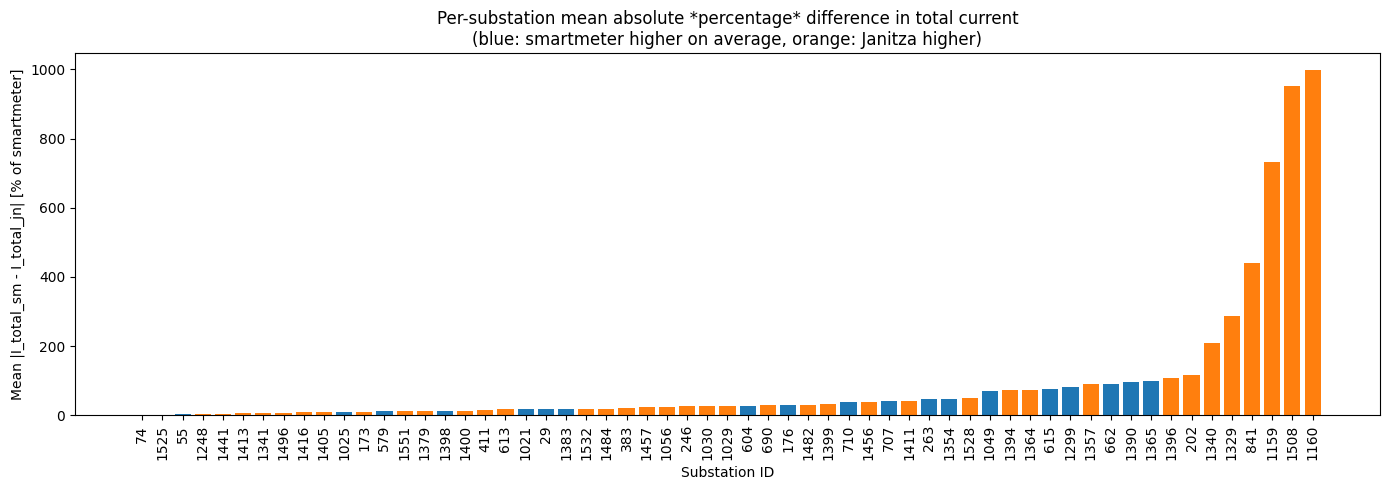

In [9]:
# Mean absolute *percentage* difference per substation (relative to smartmeter)

# Per-sample absolute percentage diff (NaN if smartmeter current is 0)
merged["I_total_abs_pct_diff"] = (
    100 * merged["I_total_diff"].abs() / merged["I_total_sm"].replace(0, np.nan)
)

# Aggregate per substation
sub_stats["mean_abs_pct_diff"] = (
    merged
    .groupby("substation_id")["I_total_abs_pct_diff"]
    .mean()
)

# Sort for nicer plotting
sub_stats_pct = sub_stats.sort_values("mean_abs_pct_diff")
x      = np.arange(len(sub_stats_pct))
height = sub_stats_pct["mean_abs_pct_diff"].to_numpy(dtype=float)
sign   = sub_stats_pct["mean_diff"].to_numpy(dtype=float)

colors  = ["tab:blue" if val > 0 else "tab:orange" for val in sign]
subs    = sub_stats_pct.index.astype(int)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x, height, color=colors)


ax.set_xticks(x)
ax.set_xticklabels(subs, rotation=90)
ax.set_xlabel("Substation ID")
ax.set_ylabel("Mean |I_total_sm - I_total_jn| [% of smartmeter]")
ax.set_title(
    "Per-substation mean absolute *percentage* difference in total current\n"
    "(blue: smartmeter higher on average, orange: Janitza higher)"
)

plt.tight_layout()
plt.show()


In [10]:
merged.head()

,substation_id,ts,I_a_sm,I_b_sm,I_c_sm,I_total_sm,n_mps,per_completed,I_a_jn,I_b_jn,I_c_jn,I_total_jn,dnr_str,I_a_diff,I_b_diff,I_c_diff,I_total_diff,I_total_abs_pct_diff
0,29,2025-11-01 12:00:00,291.245,241.86,257.570,790.675,6,0.103448,247.398941,205.307343,226.026489,678.732773,D0029,43.846059,36.552657,31.543511,111.942227,14.157805
1,29,2025-11-01 12:15:00,281.740,242.36,255.070,779.170,6,0.103448,233.248749,210.674438,227.559341,671.482529,D0029,48.491251,31.685562,27.510659,107.687471,13.820793
2,29,2025-11-01 12:30:00,268.740,245.58,255.560,769.880,6,0.103448,224.983154,207.986435,221.484894,654.454483,D0029,43.756846,37.593565,34.075106,115.425517,14.992663
3,29,2025-11-01 12:45:00,258.750,236.87,238.720,734.340,6,0.103448,219.442444,201.459366,213.465912,634.367722,D0029,39.307556,35.410634,25.254088,99.972278,13.613895
4,29,2025-11-01 13:00:00,258.755,236.46,242.385,737.600,6,0.103448,216.059448,201.753647,214.963669,632.776764,D0029,42.695552,34.706353,27.421331,104.823236,14.211393


Number of substations with n_mps >= 1: 59
Number of substations with per_completed >= 0.9: 23


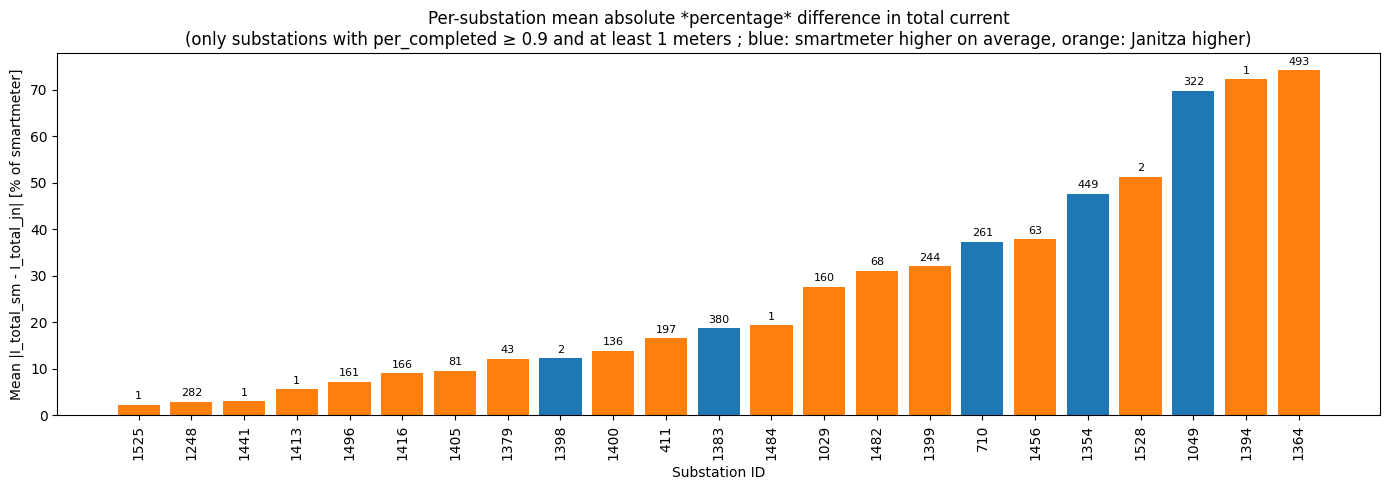

In [11]:
# Append per_completed (already in merged) aggregated per substation
sub_stats["per_completed"] = (
    merged
    .groupby("substation_id")["per_completed"]
    .max()
)
# Append n_mps (number of smartmeters) aggregated per substation
sub_stats["n_mps"] = (
    merged
    .groupby("substation_id")["n_mps"]
    .max()
)
# --- cutoff on per_completed ---
cutoff = 0.9  # change this threshold as you like
min_num = 1  # minimum number of smartmeters

sub_stats_num = sub_stats[sub_stats["n_mps"] >= min_num].copy()
print(f"Number of substations with n_mps >= {min_num}: {len(sub_stats_num)}")

sub_stats_pct = (
    sub_stats_num[sub_stats_num["per_completed"] >= cutoff]
    .sort_values("mean_abs_pct_diff")
)

print(f"Number of substations with per_completed >= {cutoff}: {len(sub_stats_pct)}")

# Plot
x      = np.arange(len(sub_stats_pct))
height = sub_stats_pct["mean_abs_pct_diff"].to_numpy(dtype=float)
sign   = sub_stats_pct["mean_diff"].to_numpy(dtype=float)
n_mps_vals = sub_stats_pct["n_mps"].to_numpy(dtype=int)
colors  = ["tab:blue" if val > 0 else "tab:orange" for val in sign]
subs    = sub_stats_pct.index.astype(int)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x, height, color=colors)

ax.set_xticks(x)
ax.set_xticklabels(subs, rotation=90)
ax.set_xlabel("Substation ID")
ax.set_ylabel("Mean |I_total_sm - I_total_jn| [% of smartmeter]")
ax.set_title(
    f"Per-substation mean absolute *percentage* difference in total current\n"
    f"(only substations with per_completed ≥ {cutoff} and at least {min_num} meters ; "
    f"blue: smartmeter higher on average, orange: Janitza higher)"
)

# --- add n_mps labels above each bar ---  # NEW
offset = 0.01 * (height.max() if len(height) else 1.0)
for xi, hi, n in zip(x, height, n_mps_vals):
    ax.text(
        xi,
        hi + offset,
        str(n),
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=0,
    )

plt.tight_layout()
plt.show()


Here we look at power

In [19]:
# Paths assuming notebook is in src/phasebalance
sm_path_power = "../data/smartmeter_15min_all_from_devices_20251101_20251103_power.parquet"
jn_path_power = "../data/janitza_3phase_P_all_20251101_1200_20251103_1200.parquet"

df_sm_power = pd.read_parquet(sm_path_power)
df_jn_power = pd.read_parquet(jn_path_power)


print("Smartmeter shape:", df_sm_power.shape)
print("Janitza shape   :", df_jn_power.shape)
print("Smartmeter cols:", df_sm_power.columns.tolist())
print("Janitza cols   :", df_jn_power.columns.tolist())

# 1) Parse dnr_str -> substation_id on the Janitza side
df_jn_power["substation_id"] = df_jn_power["dnr_str"].map(parse_dnr)

# 2) Ensure timestamps are datetime
df_sm_power["ts"] = pd.to_datetime(df_sm_power["ts"])
df_jn_power["ts"] = pd.to_datetime(df_jn_power["ts"])

# 3) Sort for sanity
df_sm_power = df_sm_power.sort_values(["substation_id", "ts"])
df_jn_power = df_jn_power.sort_values(["substation_id", "ts"])

#Change df_sm_power column names to match df_janitza_power columns. From "['substation_id', 'ts', 'I_a', 'I_b', 'I_c', 'I_total', 'n_mps', 'per_completed']" to "['substation_id', 'ts', 'P_a', 'P_b', 'P_c', 'P_total', 'n_mps', 'per_completed']"
df_sm_power = df_sm_power.rename(columns={"I_a" : "P_a", "I_b": "P_b", "I_c": "P_c", "I_total": "P_total"})

Smartmeter shape: (24565, 8)
Janitza shape   : (19299, 6)
Smartmeter cols: ['substation_id', 'ts', 'I_a', 'I_b', 'I_c', 'I_total', 'n_mps', 'per_completed']
Janitza cols   : ['ts', 'P_a', 'P_b', 'P_c', 'P_total', 'dnr_str']


In [21]:
# Force both ts columns to be UTC -> then drop timezone (naive but aligned)
df_sm_power["ts"] = pd.to_datetime(df_sm_power["ts"], utc=True).dt.tz_localize(None)
df_jn_power["ts"] = pd.to_datetime(df_jn_power["ts"], utc=True).dt.tz_localize(None)

print("df_sm ts dtype:", df_sm_power["ts"].dtype)
print("df_jn ts dtype:", df_jn_power["ts"].dtype)



# Merge on substation_id + ts (inner join = only overlapping timestamps)
merged = df_sm_power.merge(
    df_jn_power,
    on=["substation_id", "ts"],
    how="inner",
    suffixes=("_sm", "_jn"),
)

print("Merged shape:", merged.shape)
merged[["substation_id", "ts"]].head()

for col in ["P_a", "P_b", "P_c", "P_total"]:
    merged[f"{col}_diff"] = merged[f"{col}_sm"] - merged[f"{col}_jn"]

merged[["P_a_diff", "P_b_diff", "P_c_diff", "P_total_diff"]].describe()


df_sm ts dtype: datetime64[ns]
df_jn ts dtype: datetime64[ns]
Merged shape: (16210, 13)


,P_a_diff,P_b_diff,P_c_diff,P_total_diff
count,1.621000e+04,1.621000e+04,1.621000e+04,1.621000e+04
mean,1.657421e+04,-1.084288e+04,-1.244969e+04,-6.718363e+03
std,9.369295e+04,9.102135e+04,9.163814e+04,2.674595e+05
min,-1.209970e+06,-1.350138e+06,-1.198249e+06,-3.758357e+06
25%,-4.751091e+02,-1.697638e+04,-1.658948e+04,-1.577822e+04
50%,1.667088e+04,-2.474613e+03,-2.836391e+03,4.617927e+03
75%,4.907527e+04,3.957319e+03,4.308333e+03,4.387814e+04
max,2.889146e+05,2.881540e+05,2.892423e+05,8.663109e+05


Rows for substation 1400 : 288


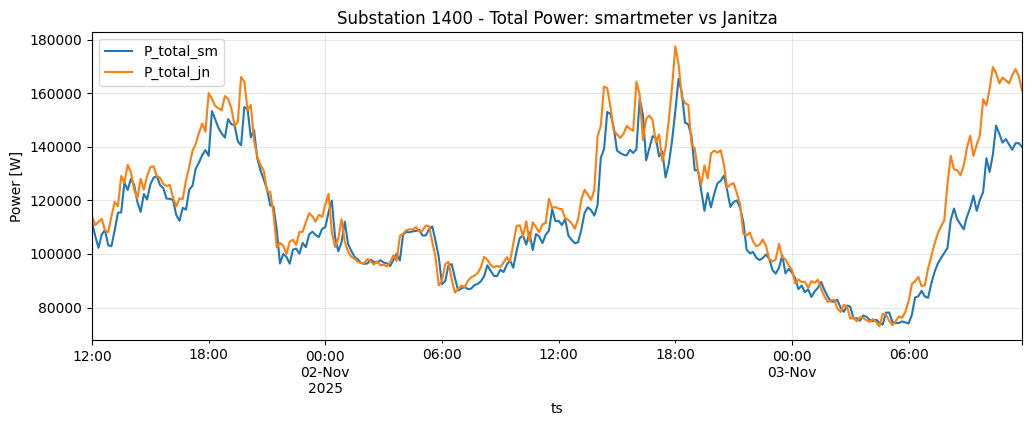

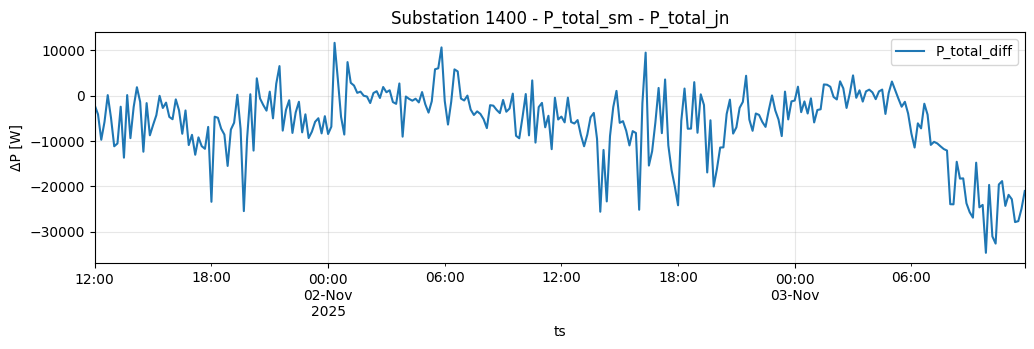

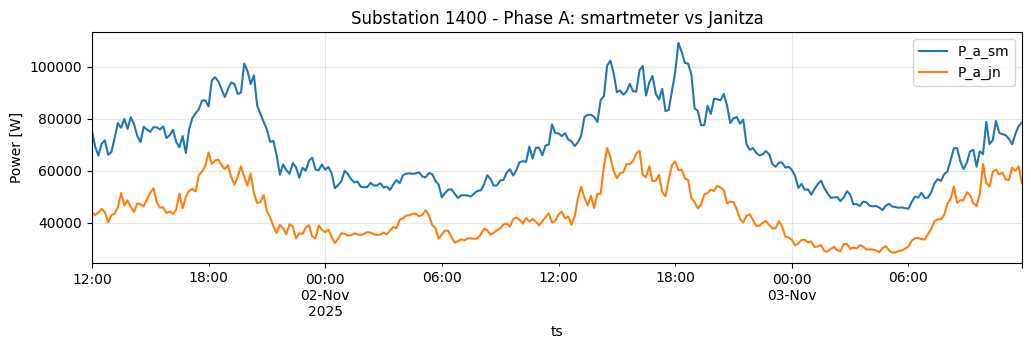

In [22]:
sub = 1400  # change this to whatever you want

sub_df = (
    merged[merged["substation_id"] == sub]
    .set_index("ts")
    .sort_index()
)

print("Rows for substation", sub, ":", sub_df.shape[0])
sub_df[["P_total_sm", "P_total_jn", "P_total_diff"]].head()

ax = sub_df[["P_total_sm", "P_total_jn"]].plot(
    figsize=(12, 4),
    title=f"Substation {sub} - Total Power: smartmeter vs Janitza",
)
ax.set_ylabel("Power [W]")
ax.grid(True, alpha=0.3)
plt.show()

ax2 = sub_df[["P_total_diff"]].plot(
    figsize=(12, 3),
    title=f"Substation {sub} - P_total_sm - P_total_jn",
)
ax2.set_ylabel("ΔP [W]")
ax2.grid(True, alpha=0.3)
plt.show()

ax3 = sub_df[["P_a_sm", "P_a_jn"]].plot(
    figsize=(12, 3),
    title=f"Substation {sub} - Phase A: smartmeter vs Janitza",
)
ax3.set_ylabel("Power [W]")
ax3.grid(True, alpha=0.3)
plt.show()


Number of substations with n_mps >= 1: 53
Number of substations with per_completed >= 0.9: 21


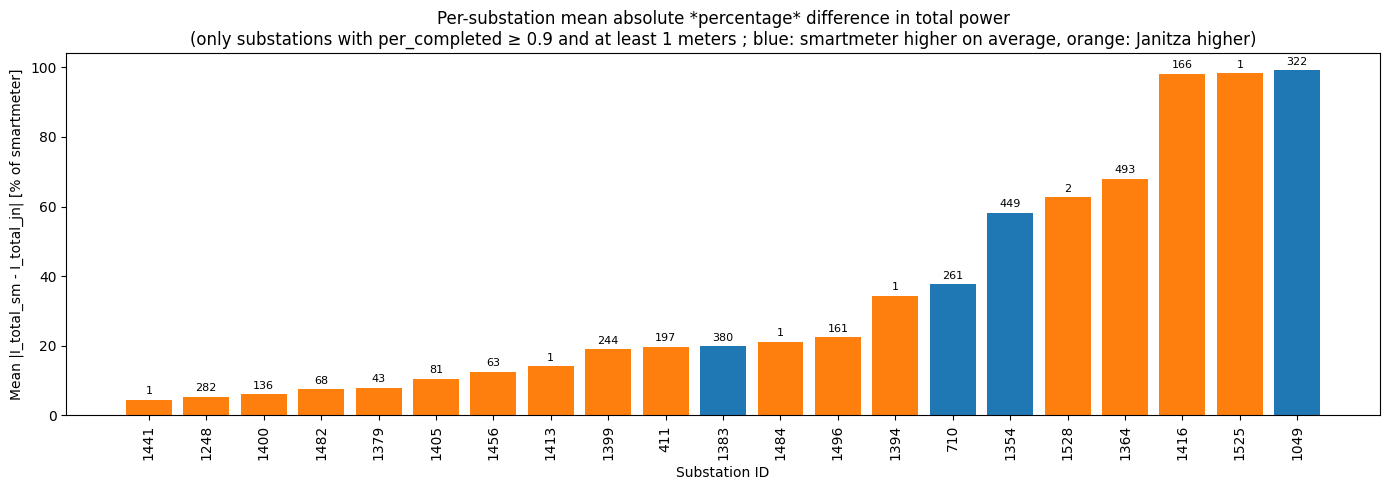

In [27]:
# Mean absolute *percentage* difference per substation (relative to smartmeter)

# Per-sample absolute percentage diff (NaN if smartmeter current is 0)
merged["P_total_abs_pct_diff"] = (
    100 * merged["P_total_diff"].abs() / merged["P_total_sm"].replace(0, np.nan)
)

# Aggregate per substation
sub_stats["mean_abs_pct_diff"] = (
    merged
    .groupby("substation_id")["P_total_abs_pct_diff"]
    .mean()
)

# Append per_completed (already in merged) aggregated per substation
sub_stats["per_completed"] = (
    merged
    .groupby("substation_id")["per_completed"]
    .max()
)
# Append n_mps (number of smartmeters) aggregated per substation
sub_stats["n_mps"] = (
    merged
    .groupby("substation_id")["n_mps"]
    .max()
)
# --- cutoff on per_completed ---
cutoff = 0.9  # change this threshold as you like
min_num = 1  # minimum number of smartmeters

sub_stats_num = sub_stats[sub_stats["n_mps"] >= min_num].copy()
print(f"Number of substations with n_mps >= {min_num}: {len(sub_stats_num)}")

sub_stats_pct = (
    sub_stats_num[sub_stats_num["per_completed"] >= cutoff]
    .sort_values("mean_abs_pct_diff")
)

print(f"Number of substations with per_completed >= {cutoff}: {len(sub_stats_pct)}")

# Plot
x      = np.arange(len(sub_stats_pct))
height = sub_stats_pct["mean_abs_pct_diff"].to_numpy(dtype=float)
sign   = sub_stats_pct["mean_diff"].to_numpy(dtype=float)
n_mps_vals = sub_stats_pct["n_mps"].to_numpy(dtype=int)
colors  = ["tab:blue" if val > 0 else "tab:orange" for val in sign]
subs    = sub_stats_pct.index.astype(int)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x, height, color=colors)

ax.set_xticks(x)
ax.set_xticklabels(subs, rotation=90)
ax.set_xlabel("Substation ID")
ax.set_ylabel("Mean |I_total_sm - I_total_jn| [% of smartmeter]")
ax.set_title(
    f"Per-substation mean absolute *percentage* difference in total power\n"
    f"(only substations with per_completed ≥ {cutoff} and at least {min_num} meters ; "
    f"blue: smartmeter higher on average, orange: Janitza higher)"
)

# --- add n_mps labels above each bar ---  # NEW
offset = 0.01 * (height.max() if len(height) else 1.0)
for xi, hi, n in zip(x, height, n_mps_vals):
    ax.text(
        xi,
        hi + offset,
        str(n),
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=0,
    )

plt.tight_layout()
plt.show()
